# Graphene Nanoribbon Density of States

This notebook builds a small bipartite honeycomb nanoribbon tight-binding model. A Gaussian polynomial energy window estimates the local density of states near selected energies.

The model is finite and deliberately small, but it captures the spectral filtering task used in graphene and nanoribbon calculations.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite graphene-like nanoribbon with two sublattices.

**QSVT implementation.** It uses Gaussian spectral-window polynomials to estimate density of states and local DOS. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact diagonalization validates the nanoribbon spectrum and near-zero weights. At scale, QSVT spectral windows are useful for density-of-states and local-response estimation without complete diagonalization.


## Variable definitions

- `graphene_ribbon_hamiltonian`: helper that builds the finite honeycomb-ribbon Hamiltonian.
- `nx`, `ny`: nanoribbon dimensions in unit cells.
- `H`: graphene-like tight-binding Hamiltonian.
- `evals`, `evecs`: exact eigenvalues and eigenvectors.
- `scaled`: rescaling metadata for the Hamiltonian.
- `scaled_evals`: eigenvalues after rescaling.
- `zero_center`: scaled energy corresponding to zero physical energy.
- `window_width`: Gaussian spectral-window width.
- `coeffs`: Gaussian-window polynomial coefficients.
- `window_operator`: polynomial zero-energy window operator.
- `zero_window_weights`: spectral weights near zero energy.
- `local_dos`: diagonal local density-of-states weights.
- `edge_sites`: site indices treated as ribbon-edge sites.
- `edge_fraction`: fraction of local DOS on edge sites.
- `centers`, `dos`, `center_scaled`: energy-window centers and DOS estimates.
- `coords`, `points`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.matrix_functions import design_gaussian_window_polynomial
from qsvt.polynomials import eval_polynomial
from qsvt.rescaling import rescale_hermitian_to_unit_interval
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
def graphene_ribbon_hamiltonian(nx, ny, hopping=1.0):
    def index(x, y, sublattice):
        return 2 * (y * nx + x) + sublattice

    n = 2 * nx * ny
    H = np.zeros((n, n), dtype=float)
    for x in range(nx):
        for y in range(ny):
            a = index(x, y, 0)
            neighbors = [(x, y), (x - 1, y), (x, y - 1)]
            for xb, yb in neighbors:
                if 0 <= xb < nx and 0 <= yb < ny:
                    b = index(xb, yb, 1)
                    H[a, b] = H[b, a] = -hopping
    return H


nx, ny = 6, 4
H = graphene_ribbon_hamiltonian(nx, ny)
evals, evecs = eigh_hermitian(H)
scaled = rescale_hermitian_to_unit_interval(H)
scaled_evals = np.linalg.eigvalsh(scaled.matrix)

zero_center = (0.0 - scaled.offset) / scaled.scale
window_width = 0.09
coeffs = design_gaussian_window_polynomial(zero_center, window_width, degree=34)
window_operator = apply_polynomial_to_hermitian(scaled.matrix, coeffs)
zero_window_weights = eval_polynomial(coeffs, scaled_evals)
local_dos = np.real(np.diag(window_operator))

edge_sites = []
for x in range(nx):
    for sub in [0, 1]:
        edge_sites.extend([2 * x + sub, 2 * ((ny - 1) * nx + x) + sub])
edge_sites = np.asarray(edge_sites)
edge_fraction = local_dos[edge_sites].sum() / local_dos.sum()
print(f"Edge Fraction [probability]: {edge_fraction}")

Edge Fraction [probability]: 0.6643744409979471


## Nanoribbon geometry

The finite honeycomb ribbon has two sublattices per unit cell and open edges in the transverse direction.


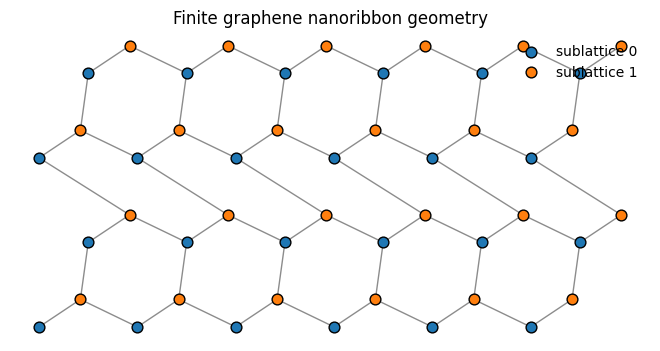

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.4), constrained_layout=True)

coords = {}
for yy in range(ny):
    for xx in range(nx):
        coords[(xx, yy, 0)] = np.array([xx + 0.5 * (yy % 2), yy * 0.86])
        coords[(xx, yy, 1)] = coords[(xx, yy, 0)] + np.array([0.42, 0.28])
for xx in range(nx):
    for yy in range(ny):
        a = coords[(xx, yy, 0)]
        for xb, yb in [(xx, yy), (xx - 1, yy), (xx, yy - 1)]:
            if (xb, yb, 1) in coords:
                b = coords[(xb, yb, 1)]
                ax.plot([a[0], b[0]], [a[1], b[1]], color="0.55", linewidth=1.0)
for sub, color in [(0, "tab:blue"), (1, "tab:orange")]:
    points = np.array([coords[(xx, yy, sub)] for yy in range(ny) for xx in range(nx)])
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=60,
        color=color,
        edgecolor="black",
        label=f"sublattice {sub}",
        zorder=3,
    )
ax.set_title("Finite graphene nanoribbon geometry")
ax.set_aspect("equal")
ax.axis("off")
ax.legend(frameon=False, loc="upper right")
plt.show()

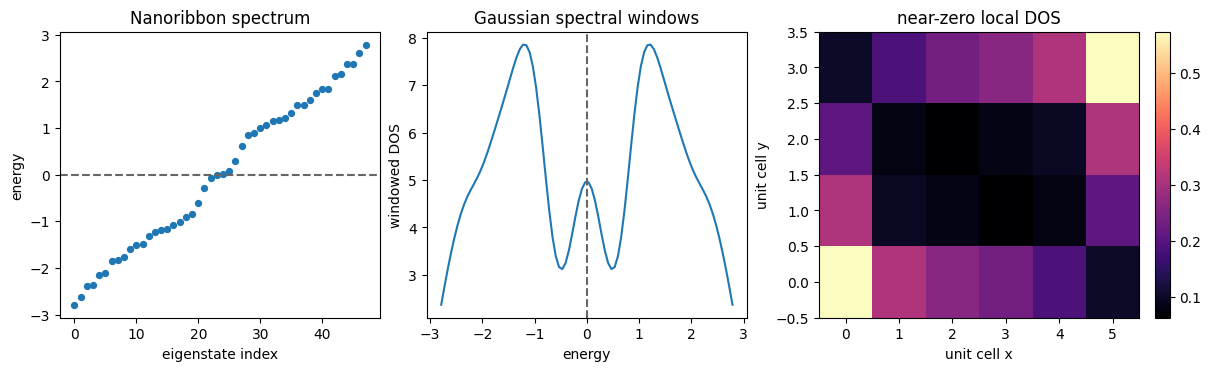

In [4]:
centers = np.linspace(evals.min(), evals.max(), 90)
dos = []
for center in centers:
    center_scaled = (center - scaled.offset) / scaled.scale
    c = design_gaussian_window_polynomial(center_scaled, window_width, degree=26)
    dos.append(np.sum(eval_polynomial(c, scaled_evals)))
dos = np.asarray(dos)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

axes[0].scatter(np.arange(len(evals)), evals, s=18)
axes[0].axhline(0.0, color="0.4", linestyle="--")
axes[0].set_xlabel("eigenstate index")
axes[0].set_ylabel("energy")
axes[0].set_title("Nanoribbon spectrum")

axes[1].plot(centers, dos)
axes[1].axvline(0.0, color="0.4", linestyle="--")
axes[1].set_xlabel("energy")
axes[1].set_ylabel("windowed DOS")
axes[1].set_title("Gaussian spectral windows")

image = local_dos.reshape(ny, nx, 2).sum(axis=2)
im = axes[2].imshow(image, origin="lower", aspect="auto", cmap="magma")
axes[2].set_xlabel("unit cell x")
axes[2].set_ylabel("unit cell y")
axes[2].set_title("near-zero local DOS")
fig.colorbar(im, ax=axes[2], fraction=0.046)

plt.show()

In [5]:
assert H.shape == (2 * nx * ny, 2 * nx * ny)
assert np.allclose(H, H.T)
assert np.max(np.abs(evals + evals[::-1])) < 1e-10
assert np.sum(zero_window_weights) > 1.0
assert edge_fraction > 0.35

print(f"near_zero_window_weight: {np.sum(zero_window_weights):.3f}")
print(f"edge_fraction_of_near_zero_ldos [probability]: {edge_fraction:.3f}")
print("validation: passed")

near_zero_window_weight: 5.032
edge_fraction_of_near_zero_ldos [probability]: 0.664
validation: passed
